In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

In [3]:
df = pd.read_csv("Housing.csv")

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.shape

(545, 13)

In [6]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [7]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [9]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [10]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0


In [13]:
missing_values[missing_values > 0].count()

np.int64(0)

In [14]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent[missing_percent > 0].sort_values(ascending=False)

,0


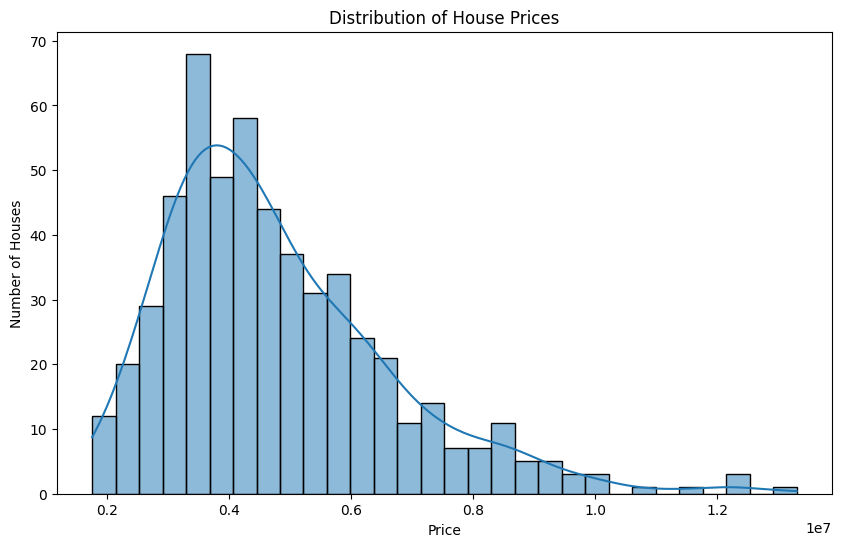

In [15]:
# Exploratory Data Analysis      Price Distribution
plt.figure(figsize=(10,6))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

In [16]:
numerical_columns = df.select_dtypes(include=['int64', 'float64'])

numerical_columns.head()

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2


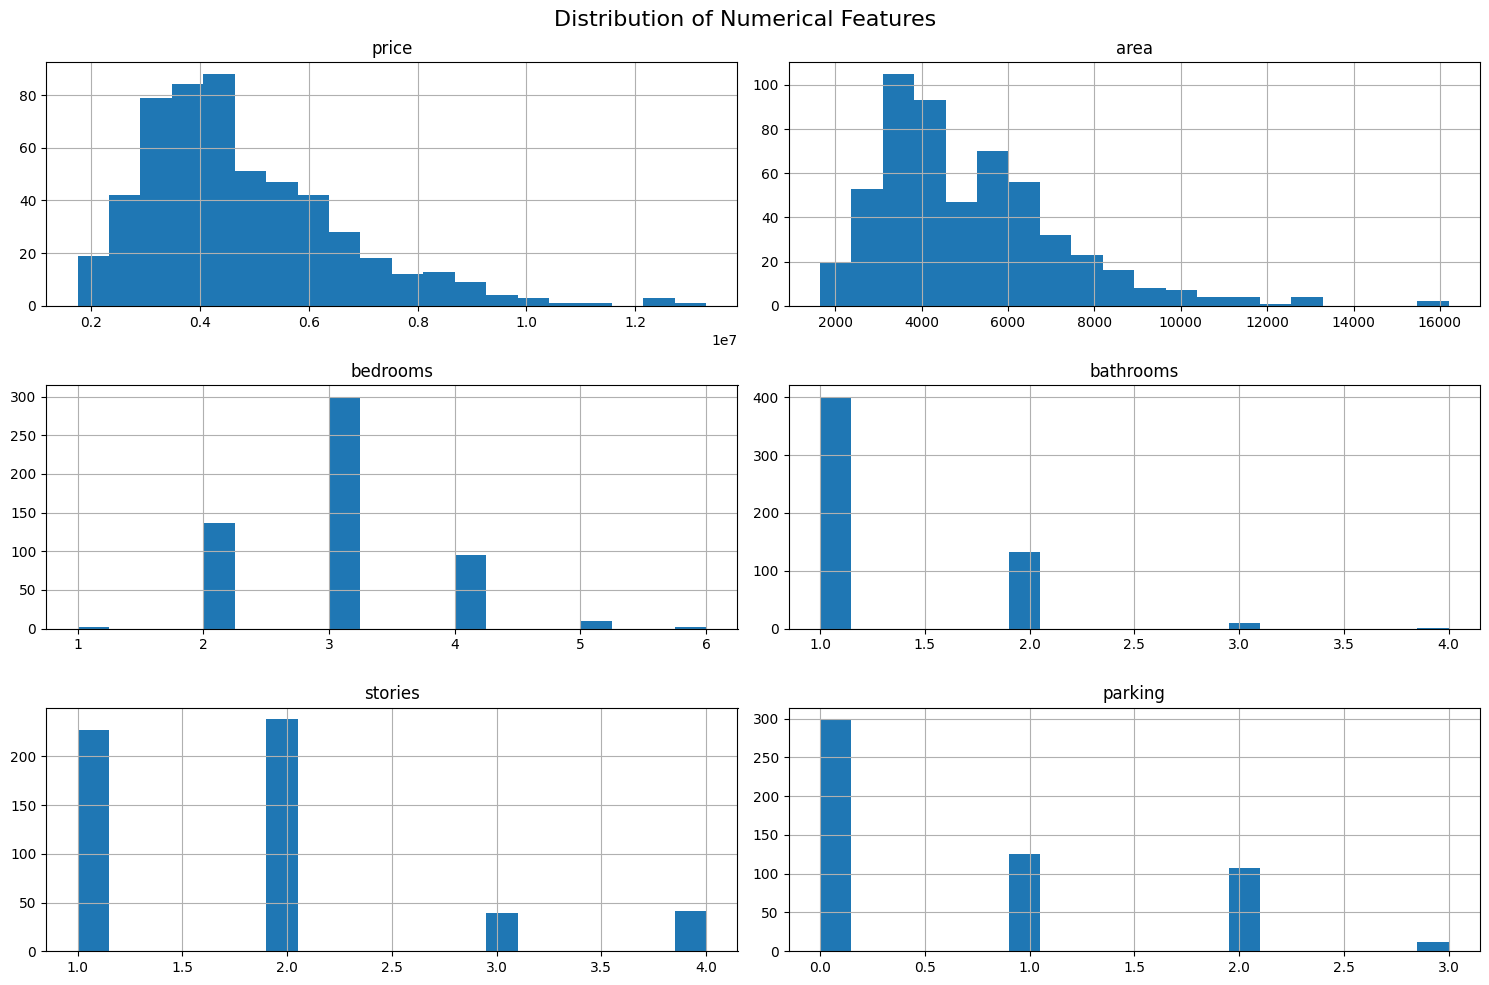

In [17]:
# Plot Histograms for All Numerical Columns
numerical_columns.hist(figsize=(15,10), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()

plt.show()

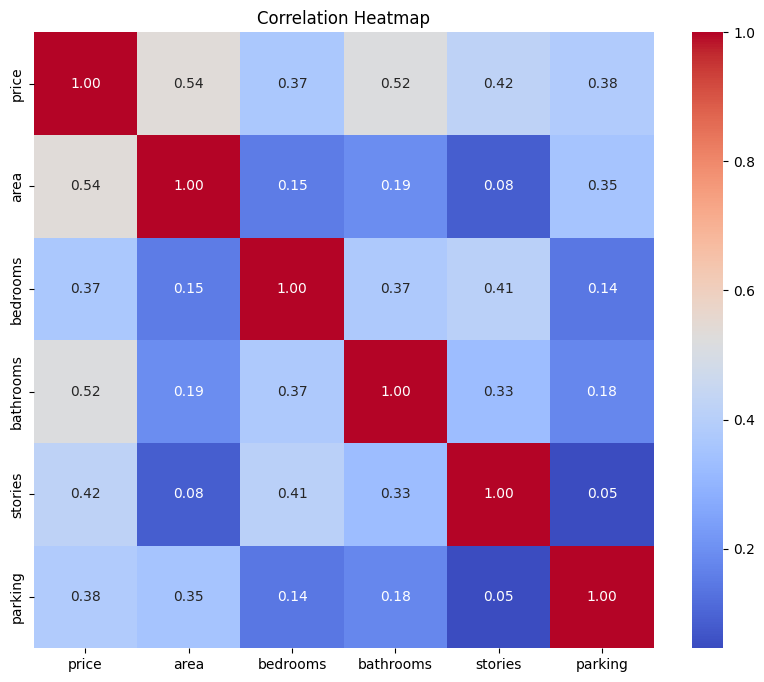

In [18]:
# Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [19]:
categorical_columns = df.select_dtypes(include='object')

categorical_columns.columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [20]:
df["airconditioning"].value_counts()

,count
airconditioning,
no,373
yes,172


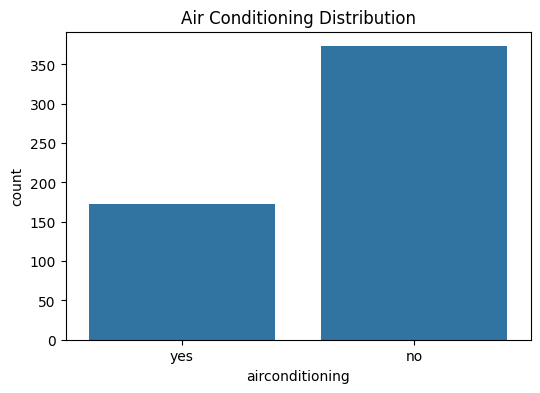

In [21]:
# Visualize Air Conditioning
plt.figure(figsize=(6,4))

sns.countplot(x="airconditioning", data=df)

plt.title("Air Conditioning Distribution")

plt.show()

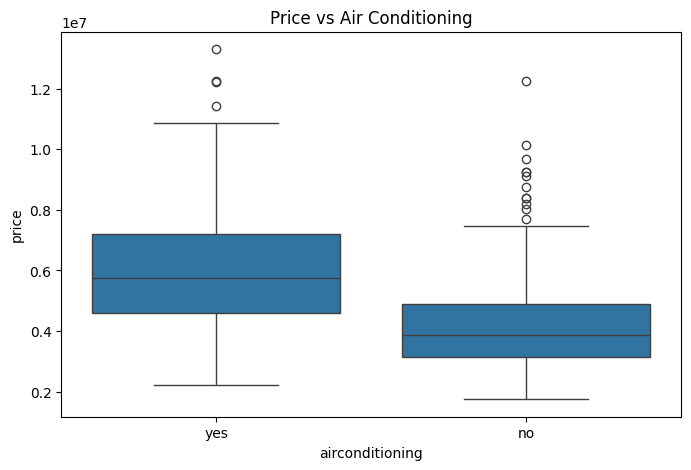

In [22]:
# Does Air Conditioning Affect Price?
plt.figure(figsize=(8,5))

sns.boxplot(x="airconditioning", y="price", data=df)

plt.title("Price vs Air Conditioning")

plt.show()

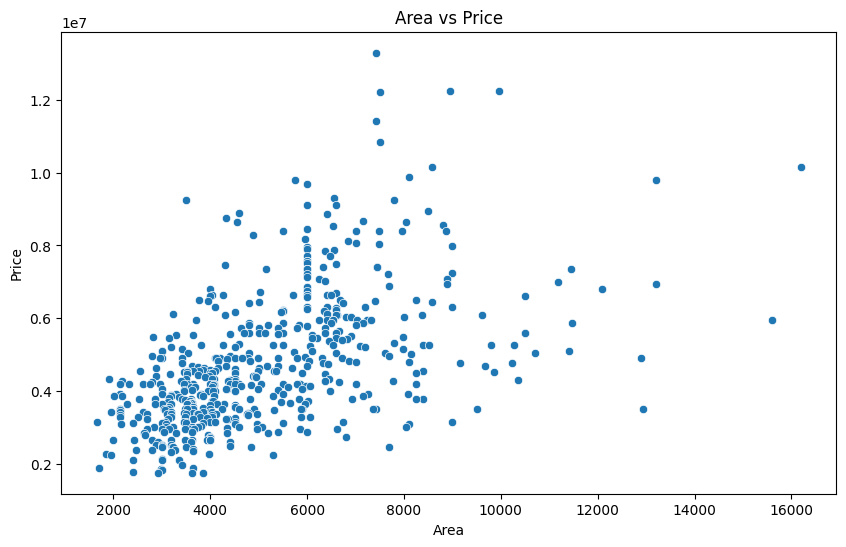

In [23]:
# scatter
plt.figure(figsize=(10,6))

sns.scatterplot(x="area", y="price", data=df)

plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

In [24]:
# Data Preprocessing
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [25]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [26]:
df.select_dtypes(include='object').columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [27]:
# Encoding (Converting Text into Numbers)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = le.fit_transform(df[column])


In [28]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [29]:
# Preparing Data for Machine Learning
# Features (Independent Variables)
X = df.drop("price", axis=1)

# Target (Dependent Variable)
y = df["price"]

In [30]:
print(X.head())

   area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0  7420         4          2        3         1          0         0   
1  8960         4          4        4         1          0         0   
2  9960         3          2        2         1          0         1   
3  7500         4          2        2         1          0         1   
4  7420         4          1        2         1          1         1   

   hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  
0                0                1        2         1                 0  
1                0                1        3         0                 0  
2                0                0        2         1                 1  
3                0                1        3         1                 0  
4                0                1        2         0                 0  


In [31]:
print(y.head())

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64


In [32]:
# Train-Test Split
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

X_train shape : (436, 12)
X_test shape  : (109, 12)
y_train shape : (436,)
y_test shape  : (109,)


In [35]:
# Linear Regression
from sklearn.linear_model import LinearRegression

In [36]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [37]:
# Compare Actual vs Predicted
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

results.head(10)

,Actual Price,Predicted Price
316,4060000,5.203692e+06
77,6650000,7.257004e+06
360,3710000,3.062829e+06
90,6440000,4.559592e+06
493,2800000,3.332932e+06
209,4900000,3.563081e+06
176,5250000,5.645466e+06
249,4543000,6.413980e+06
516,2450000,2.755832e+06
426,3353000,2.668939e+06


In [38]:
# Model Evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [39]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

In [40]:
print("Mean Absolute Error (MAE):", mae)

print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", rmse)

print("R² Score:", r2)

Mean Absolute Error (MAE): 979679.6912959901
Mean Squared Error (MSE): 1771751116594.0352
Root Mean Squared Error (RMSE): 1331071.4167895108
R² Score: 0.6494754192267803


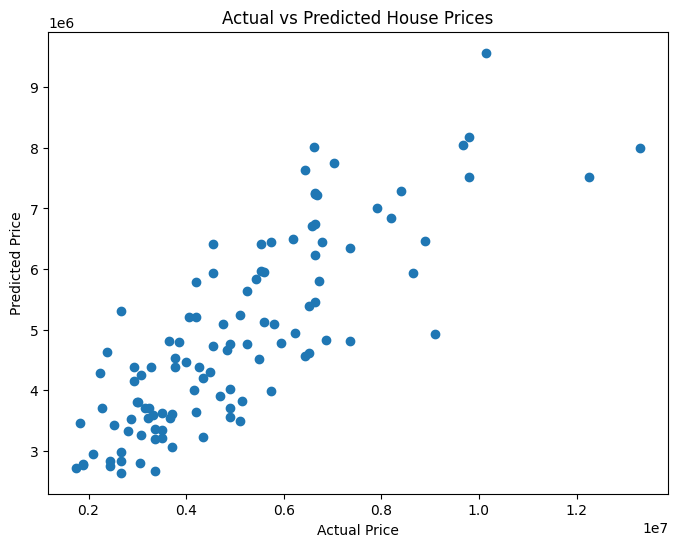

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [42]:
# View the Model Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,area,2.358488e+02
1,bedrooms,7.857449e+04
2,bathrooms,1.097117e+06
3,stories,4.062232e+05
4,mainroad,3.668242e+05
5,guestroom,2.331468e+05
6,basement,3.931598e+05
7,hotwaterheating,6.878813e+05
8,airconditioning,7.855506e+05
9,parking,2.257565e+05


In [43]:
# Sort the Features
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
2,bathrooms,1.097117e+06
8,airconditioning,7.855506e+05
7,hotwaterheating,6.878813e+05
10,prefarea,6.299017e+05
3,stories,4.062232e+05
6,basement,3.931598e+05
4,mainroad,3.668242e+05
5,guestroom,2.331468e+05
9,parking,2.257565e+05
1,bedrooms,7.857449e+04


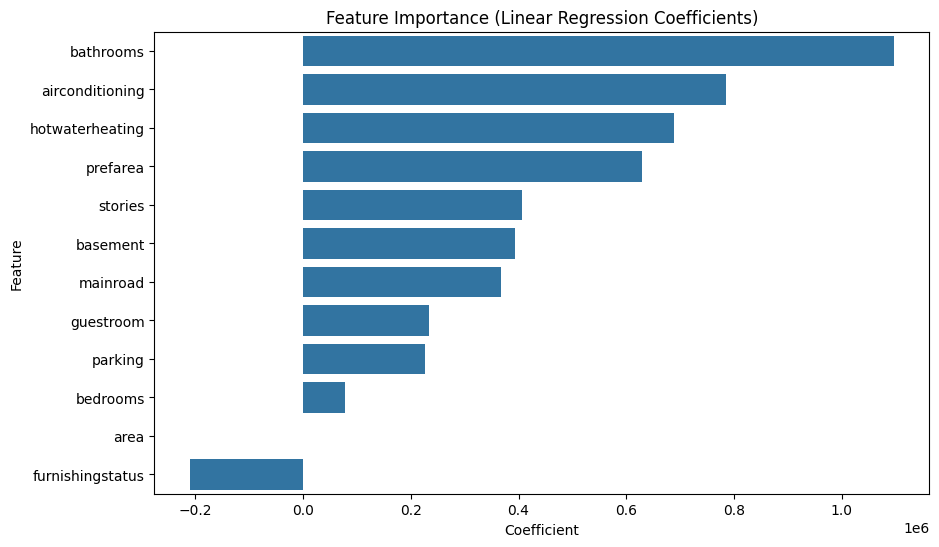

In [44]:
# Visualize Feature Importance
plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coefficients
)

plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()

In [45]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [46]:
import os

os.listdir()

['.config', 'house_price_model.pkl', 'Housing.csv', 'sample_data']

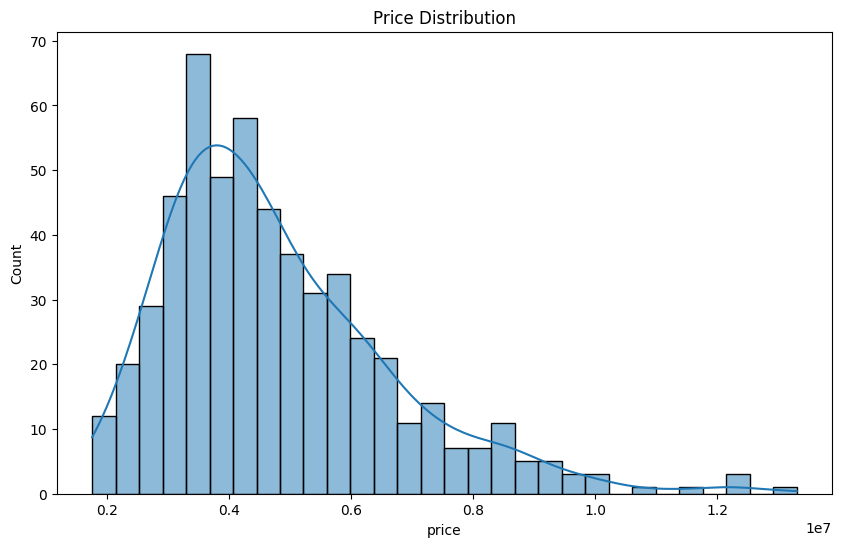

In [47]:
plt.figure(figsize=(10,6))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Price Distribution")

plt.savefig("price_distribution.png")

plt.show()